In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/top-250-imdb-movie-dataset/top_250_imdb_dataset.csv


# Imports & Loading Dataset

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Esto hace que los gráficos se vean integrados en el notebook
%matplotlib inline 
sns.set_theme(style="whitegrid")

df = pd.read_csv('/kaggle/input/top-250-imdb-movie-dataset/top_250_imdb_dataset.csv')

In [3]:
# Ver las primeras 5 filas
df.head()

,Rank,Title,Year,Rating,Duration_Minutes,Certificate,Source
0,1,The Shawshank Redemption,1994,NaN,142,R,IMDb Top 250
1,2,The Godfather,1972,NaN,175,R,IMDb Top 250
2,3,The Dark Knight,2008,NaN,152,PG-13,IMDb Top 250
3,4,The Godfather Part II,1974,NaN,202,R,IMDb Top 250
4,5,12 Angry Men,1957,NaN,96,Approved,IMDb Top 250


In [4]:
# Resumen de tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Rank              250 non-null    int64  
 1   Title             250 non-null    object 
 2   Year              250 non-null    int64  
 3   Rating            0 non-null      float64
 4   Duration_Minutes  250 non-null    int64  
 5   Certificate       245 non-null    object 
 6   Source            250 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 13.8+ KB


**Hay 250 filas, con todos los Rating en nulo y 5 nulos en Certificate. Se eliminara la columna Rating ya que no aporta nada, y se rellenaran los Certificate faltantes.**

Rank                  0
Title                 0
Year                  0
Rating              250
Duration_Minutes      0
Certificate           5
Source                0
dtype: int64


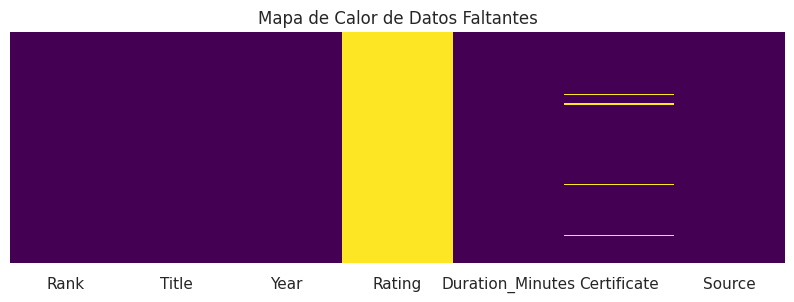

In [5]:
print(df.isnull().sum())
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Calor de Datos Faltantes')
plt.show()

In [6]:
# Elimina la columna Rating
df = df.drop('Rating',axis=1)

In [7]:
# Muestra las filas donde el Certificate es nulo
filas_con_nulos = df[df['Certificate'].isnull()]
display(filas_con_nulos.head())

,Rank,Title,Year,Duration_Minutes,Certificate,Source
68,69,12th Fail,2023,147,NaN,IMDb Top 250
77,78,Your Name.,2016,106,NaN,IMDb Top 250
78,79,Das Boot,1981,149,NaN,IMDb Top 250
165,166,The Chaos Class Failed the Class,1975,95,NaN,IMDb Top 250
220,221,Maharaja,2024,141,NaN,IMDb Top 250


In [8]:
df['Certificate'] = df['Certificate'].fillna('Non-Certificate')
no_cert = df[df['Certificate'] == 'Non-Certificate']
print(no_cert)

     Rank                             Title  Year  Duration_Minutes  \
68     69                         12th Fail  2023               147   
77     78                        Your Name.  2016               106   
78     79                          Das Boot  1981               149   
165   166  The Chaos Class Failed the Class  1975                95   
220   221                          Maharaja  2024               141   

         Certificate        Source  
68   Non-Certificate  IMDb Top 250  
77   Non-Certificate  IMDb Top 250  
78   Non-Certificate  IMDb Top 250  
165  Non-Certificate  IMDb Top 250  
220  Non-Certificate  IMDb Top 250  


Rank                0
Title               0
Year                0
Duration_Minutes    0
Certificate         0
Source              0
dtype: int64


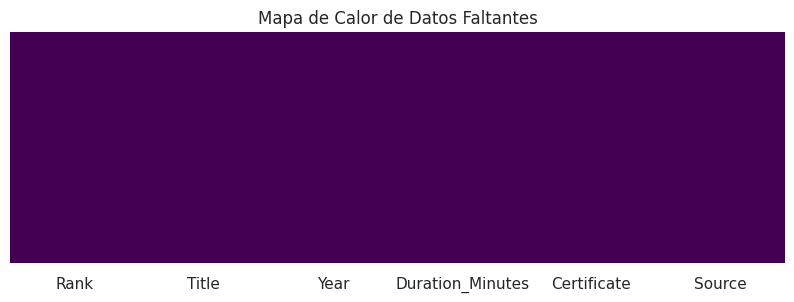

In [9]:
print(df.isnull().sum())
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Calor de Datos Faltantes')
plt.show()

In [10]:
# Estadísticas básicas (media, máximo, mínimo)
df.describe()

,Rank,Year,Duration_Minutes
count,250.000000,250.000000,250.000000
mean,125.500000,1988.620000,131.516000
std,72.312977,25.552442,35.747128
min,1.000000,1921.000000,45.000000
25%,63.250000,1973.000000,108.250000
50%,125.500000,1995.000000,127.500000
75%,187.750000,2009.000000,147.750000
max,250.000000,2025.000000,374.000000


# Distribución de columna Year

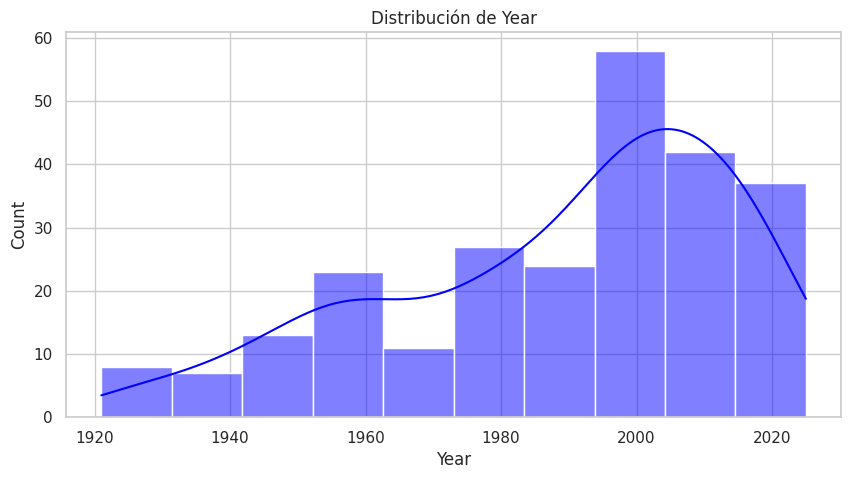

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Year'], kde=True, color='blue')
plt.title('Distribución de Year')
plt.show()

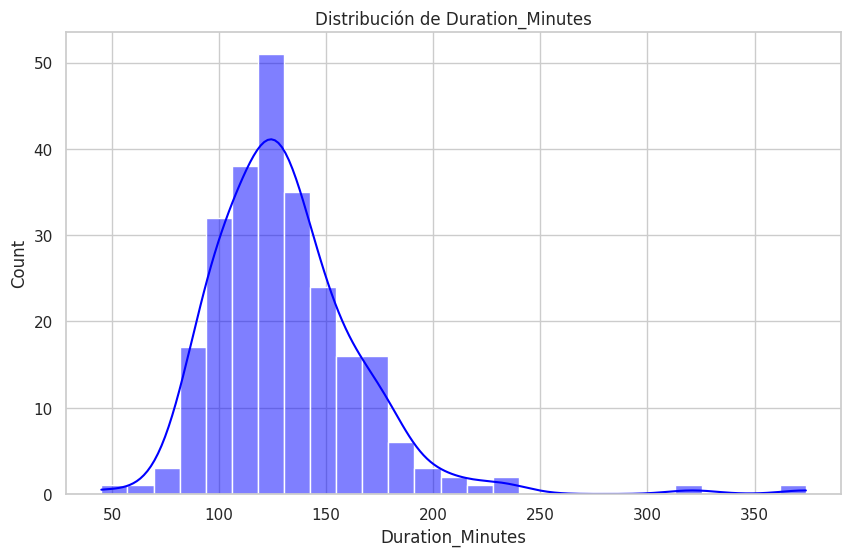

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Duration_Minutes'], kde=True, color='blue')
plt.title('Distribución de Duration_Minutes')
plt.show()

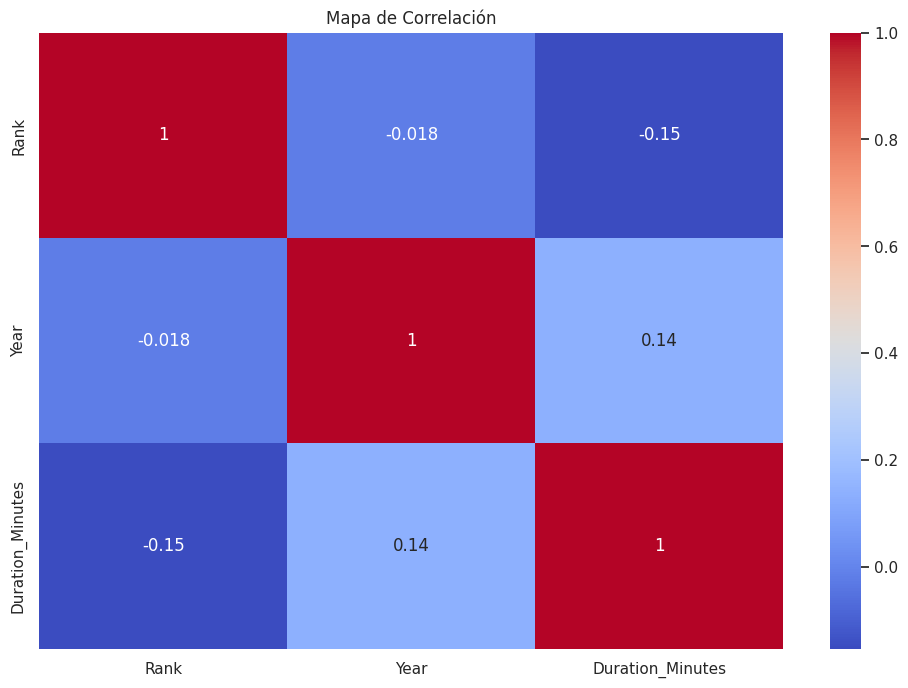

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Mapa de Correlación')
plt.show()